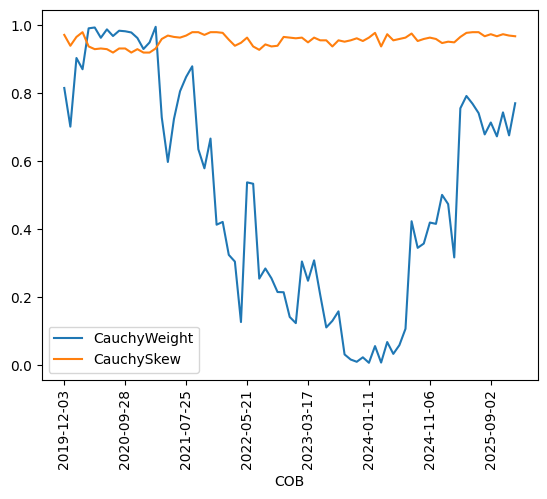

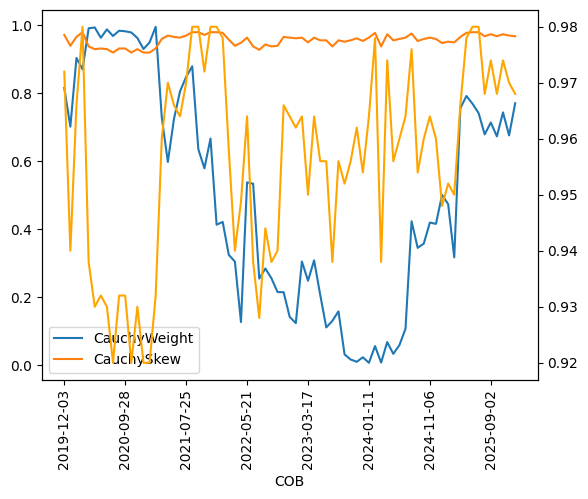

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dfs = []
for i in range(11):
    skew = str(90 + i)
    df = pd.read_csv(f'C:\\dev\\MLCopula\\data\\weights\\OptimalCopulaGCS{skew}.csv')
    #df = df.drop(['CauchySkew'], axis=1)
    df = df.rename(columns={'CauchyWeight': 'CauchyWeight' + skew, 
                            'Error': 'Error' + skew, 
                            'CauchySkew': 'CauchySkew' + skew })
    df = df.set_index('COB')
    dfs.append(df)

res = pd.concat(dfs, axis=1)

def process(row):
    weights = [row['Error' + str(90 + i)] for i in range(11)]
    weights_min = min(weights)
    weights = [w - weights_min for w in weights]
    sum_weights = sum(weights)
    weights = [w/sum_weights for w in weights]

    cw = sum([row['CauchyWeight' + str(90 + i)]*weights[i] for i in range(11)])
    cs = sum([row['CauchySkew' + str(90 + i)]*weights[i] for i in range(11)])

    return (cw,cs)


def process2(row):
    weights = np.array([row['Error' + str(90 + i)] for i in range(11)])
    i_min= np.argmin(weights)

    cw_list = [row['CauchyWeight' + str(90 + i)] for i in range(11)]
    cs_list = [row['CauchySkew' + str(90 + i)] for i in range(11)]

    cw = cw_list[i_min]
    cs = cs_list[i_min]
    w = weights[i_min]

    return (cw,cs)


def process3(row, nmin=5):
    weightsall = [row['Error' + str(90 + i)] for i in range(11)]
    smallestval = []
    smallest = []
    for _ in range(nmin):
        smallestval.append(min(weightsall))
        weightsall.remove(min(weightsall))

    weightsall = [row['Error' + str(90 + i)] for i in range(11)]
    for i in range(11):
        if weightsall[i] in smallestval:
            smallest.append(i)

    weights = [row['Error' + str(90 + i)] for i in smallest]
    weights_min = min(weights)
    weights = [w - weights_min for w in weights]
    sum_weights = sum(weights)
    weights = [w/sum_weights for w in weights]

    cw = sum([row['CauchyWeight' + str(90 + i)] for i in smallest])/len(smallest)
    cs = sum([row['CauchySkew' + str(90 + i)] for i in smallest])/len(smallest)

    return (cw,cs)

res['Temp'] = res.apply(lambda row: process3(row) , axis=1)
res['CauchyWeight'] = res.apply(lambda row: row['Temp'][0], axis=1)
res['CauchySkew'] = res.apply(lambda row: row['Temp'][1], axis=1)
#res['Error'] = res.apply(lambda row: row['Temp'][2], axis=1)

res = res[['CauchyWeight', 'CauchySkew']]

res.plot(rot=90)#.legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{'Average params'}')

plt.show()
#plt.savefig(f'{figpath}\\{run_name}.png', bbox_inches="tight")

res.plot(rot=90)
plt.twinx()
plt.plot(res['CauchySkew'], color= 'orange') 
plt.show()